# Unidad 4 · RCPSP: precedencias generalizadas y la restricción que todos escriben mal

**Planta:** Conservas del Itata S.A. — cierre anual de planta
**Datos:** `DatosClases/4_Secuenciamiento/itata_rcpsp.csv` (18 actividades),
`itata_rcpsp_recursos.csv` (6 mecánicos, 1 grúa),
`itata_rcpsp_precedencias.csv` (4 relaciones generalizadas)
**Solver:** Gurobi

---

## Qué se decide aquí

Dos semanas al año la fábrica para entera para mantención mayor. Son las
mismas semanas ISO 5 y 6 que en la Unidad 2 aparecían como despachos en cero,
y cada hora de atraso es una hora más sin producir. Hay 18 actividades, una
cuadrilla de 6 mecánicos y **una** grúa.

Esto ya no es un taller. No hay máquinas que asignar: hay actividades que
consumen recursos **acumulables** —tres mecánicos aquí, cuatro allá— y que
pueden correr en paralelo mientras la suma no exceda la cuadrilla. Es el
**RCPSP** (*resource-constrained project scheduling problem*), y trae dos
cosas que no estaban en los cuadernos 01 a 05:

1. Una **formulación indexada en el tiempo**, con una binaria por actividad y
   por instante, en vez de una binaria por par. Tiene una restricción de
   recurso que es la más fácil de escribir mal de toda la unidad.
2. **Precedencias generalizadas**: no solo "A termina y después empieza B",
   sino las cuatro formas FS, SS, FF y SF, con desfases que pueden ser
   negativos.

## La pregunta del cuaderno

El modelo clásico de proyectos —el que está en todo texto de gestión de
operaciones y en todo software de carta Gantt— solo sabe escribir una relación:
**fin → inicio con desfase cero**. Todo lo demás se aproxima a mano o se
ignora.

La tentación es pensar que generalizar las precedencias sirve para *acortar*
el proyecto, porque permite solapar actividades. Este cuaderno muestra que esa
lectura está a mitad de camino, y que la otra mitad va **en la dirección
contraria**. Se resuelve el mismo proyecto tres veces:

| precedencias | CPM | óptimo con recursos |
|---|---|---|
| solo FS con desfase 0 (el modelo clásico) | **63 h** | **78 h** |
| + las relaciones SS, FF y SF que la planta sí tiene | **65 h** | **80 h** |
| + el desfase negativo de A11 → A13 | **62 h** | **77 h** |

Cotas por recurso: **57,5 h** (mecánicos) y **44,0 h** (grúa).

El plan clásico de 78 h no era optimista: era **inejecutable**. Escribir las
relaciones que la planta realmente tiene lo empuja a 80 h. Recién después,
permitir el solapamiento que la planta realmente permite lo baja a 77 h.
Generalizar las precedencias no es "optimizar más": es dejar de mentir en las
dos direcciones a la vez.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

act = pd.read_csv(datos("4_Secuenciamiento", "itata_rcpsp.csv"))
rec = pd.read_csv(datos("4_Secuenciamiento", "itata_rcpsp_recursos.csv"))
gen = pd.read_csv(datos("4_Secuenciamiento", "itata_rcpsp_precedencias.csv"))

ACT = list(act.actividad)
nombre = dict(zip(act.actividad, act.nombre))
dur = {r.actividad: int(r.duracion_h) for _, r in act.iterrows()}
RECURSOS = list(rec.recurso)
cap = {r.recurso: int(r.capacidad) for _, r in rec.iterrows()}
uso = ({(r.actividad, "mecanicos"): int(r.uso_mecanicos) for _, r in act.iterrows()} |
       {(r.actividad, "grua"): int(r.uso_grua) for _, r in act.iterrows()})

# Los predecesores clásicos tal como vienen en el archivo.
preds_archivo = {r.actividad: ([] if not isinstance(r.predecesores, str)
                               or not r.predecesores.strip()
                               else r.predecesores.split())
                 for _, r in act.iterrows()}

GENERALIZADAS = [(r.antecesora, r.sucesora, str(r.tipo).upper(),
                  float(r.desfase_h), r.motivo) for _, r in gen.iterrows()]

print(f"{len(ACT)} actividades · {sum(dur.values())} h de trabajo total")
print(f"Recursos: " + ", ".join(f"{r} = {cap[r]}" for r in RECURSOS))
print()
print(act[["actividad", "nombre", "duracion_h", "uso_mecanicos", "uso_grua",
           "predecesores"]].fillna("").to_string(index=False))

18 actividades · 126 h de trabajo total
Recursos: mecanicos = 6, grua = 1

actividad                               nombre  duracion_h  uso_mecanicos  uso_grua predecesores
      A01         Bloqueo y descarga de lineas           4              3         0             
      A02         Vaciado y lavado de marmitas           8              4         0          A01
      A03 Desmontaje de valvulas del autoclave           6              2         1          A01
      A04   Inspeccion de recipiente a presion          10              2         0          A03
      A05             Cambio de empaquetaduras           5              2         0          A03
      A06        Reparacion de camisa de vapor          12              3         1          A02
      A07          Calibracion de instrumentos           6              1         0      A04 A05
      A08       Cambio de cabezal llenadora L1           9              3         1          A01
      A09             Ajuste de capsuladora L2      

## 1. Las cuatro relaciones que el archivo trae aparte

Las precedencias generalizadas viven en su propio archivo, y eso es
deliberado: una relación es un vínculo **entre dos actividades**, con un tipo
y un desfase, no un atributo de la sucesora. Meterlas en la columna
`predecesores` obligaría a codificar tipo y desfase dentro de un string, que
es la forma más rápida de que nadie las vuelva a leer.

Cada una viene con su motivo, y el motivo es el dato importante: ninguna de
las cuatro es un refinamiento técnico, las cuatro son cosas que pasan en la
planta y que el modelo clásico simplemente no podía escribir.

In [2]:
print("Relaciones generalizadas:\n")
for (a, b, tipo, lag, motivo) in GENERALIZADAS:
    print(f"  {a} -> {b}   {tipo}  desfase {lag:+g} h")
    print(f"      {nombre[a]}  ->  {nombre[b]}")
    print(f"      {motivo}\n")

print("Atención al detalle del archivo: A11 NO aparece en la lista de")
print(f"predecesores clásicos de A13 (A13 tiene: {preds_archivo['A13']}),")
print("porque su relación con A13 es precisamente el FS con desfase negativo.")
print("Para armar la versión CLÁSICA del proyecto hay que volver a agregarlo:")
print("si no, la comparación de las tres versiones estaría comparando también")
print("una precedencia que se perdió por el camino.")

Relaciones generalizadas:

  A11 -> A13   FS  desfase -3 h
      Mantencion de caldera  ->  Pruebas hidraulicas
      las ultimas 3 h de la caldera son aislacion y papeleo: las pruebas hidraulicas ya pueden partir

  A15 -> A16   SS  desfase +2 h
      Marcha blanca de linea 1  ->  Marcha blanca de linea 2
      la cuadrilla no puede arrancar las dos lineas a la vez; L2 parte 2 h despues que L1

  A16 -> A15   FF  desfase -4 h
      Marcha blanca de linea 2  ->  Marcha blanca de linea 1
      ambas deben quedar listas para la misma validacion: L1 no puede terminar mas de 4 h antes que L2

  A15 -> A12   SF  desfase +0 h
      Marcha blanca de linea 1  ->  Sanitizacion general
      la sanitizacion no se cierra hasta que arranca la marcha blanca: la superficie sanitizada se recontamina si queda tiempo muerto

Atención al detalle del archivo: A11 NO aparece en la lista de
predecesores clásicos de A13 (A13 tiene: ['A07']),
porque su relación con A13 es precisamente el FS con desfase negat

## 2. Las cuatro formas se reducen a una sola desigualdad

Este es el resultado que hace manejable toda la generalización. Sean `S_a` y
`S_b` los instantes de inicio y `d_a`, `d_b` las duraciones. Las cuatro
relaciones dicen cosas distintas en castellano y **la misma cosa en álgebra**:

| tipo | qué exige | desigualdad nativa | reducida a inicios |
|---|---|---|---|
| **FS** fin → inicio | `b` empieza después de que `a` termina | `S_b ≥ (S_a + d_a) + lag` | `δ = d_a + lag` |
| **SS** inicio → inicio | `b` empieza después de que `a` empieza | `S_b ≥ S_a + lag` | `δ = lag` |
| **FF** fin → fin | `b` termina después de que `a` termina | `S_b + d_b ≥ (S_a + d_a) + lag` | `δ = d_a + lag − d_b` |
| **SF** inicio → fin | `b` termina después de que `a` empieza | `S_b + d_b ≥ S_a + lag` | `δ = lag − d_b` |

Las cuatro colapsan en

$$S_b \;\ge\; S_a + \delta(a,b)$$

y el desfase `lag` puede ser positivo (hay que esperar), cero (el caso
clásico) o **negativo** (se permite solapar).

**En el MIP cambia un coeficiente.** Literalmente eso: una resta en el término
independiente. Si alguien presenta las precedencias generalizadas como una
extensión difícil del modelo, no las ha escrito.

Lo que cambia de verdad está **afuera** del MIP, y es el tema de la sección 3.

In [3]:
def delta(a, b, tipo, lag):
    """Traduce una relación de cualquiera de las cuatro formas a S_b - S_a."""
    da, db = dur[a], dur[b]
    t = tipo.upper()
    if t == "FS":
        return da + lag
    if t == "SS":
        return lag
    if t == "FF":
        return da + lag - db
    if t == "SF":
        return lag - db
    raise ValueError(f"tipo de precedencia desconocido: {tipo}")


filas_delta = []
for (a, b, tipo, lag, _motivo) in GENERALIZADAS:
    filas_delta.append({"antecesora": a, "sucesora": b, "tipo": tipo,
                        "desfase_h": lag, "d_a": dur[a], "d_b": dur[b],
                        "delta": delta(a, b, tipo, lag)})
tabla_delta = pd.DataFrame(filas_delta)
print("Traducción de las cuatro relaciones del archivo:\n")
print(tabla_delta.to_string(index=False))
print("\nDos de las cuatro deltas salen NEGATIVAS. Una delta negativa dice que")
print("la sucesora puede empezar ANTES que la antecesora, y es perfectamente")
print("legítima: 'B no puede terminar más de 4 h antes que A' no ordena nada.")

Traducción de las cuatro relaciones del archivo:

antecesora sucesora tipo  desfase_h  d_a  d_b  delta
       A11      A13   FS       -3.0   14    5   11.0
       A15      A16   SS        2.0    6    6    2.0
       A16      A15   FF       -4.0    6    6   -4.0
       A15      A12   SF        0.0    6    6   -6.0

Dos de las cuatro deltas salen NEGATIVAS. Una delta negativa dice que
la sucesora puede empezar ANTES que la antecesora, y es perfectamente
legítima: 'B no puede terminar más de 4 h antes que A' no ordena nada.


### Las tres versiones del mismo proyecto

Para poder comparar, se arman tres juegos de relaciones sobre las **mismas**
18 actividades, las mismas duraciones y los mismos recursos:

* **clásica** — todo FS con desfase 0, incluyendo A11 → A13, que hay que
  reponer porque el archivo lo sacó de la columna de predecesores.
* **generalizada** — la clásica más las relaciones SS, FF y SF que la planta
  tiene. A11 → A13 se deja todavía como FS con desfase 0.
* **con solapamiento** — la anterior, pero ahora A11 → A13 con su desfase real
  de −3 h.

El orden importa: se agrega **primero** lo que restringe y **después** lo que
libera. Mezclar los dos pasos es lo que produce la conclusión equivocada.

In [4]:
def relaciones(variante):
    """Lista de (a, b, delta, tipo, lag) para una de las tres versiones."""
    pr = {b: list(v) for b, v in preds_archivo.items()}
    if variante in ("clasica", "generalizada"):
        pr["A13"] = sorted(set(pr["A13"]) | {"A11"})   # reponer el FS clásico
    out = [(a, b, delta(a, b, "FS", 0.0), "FS", 0.0)
           for b, ps in pr.items() for a in ps]
    if variante == "clasica":
        return out
    for (a, b, tipo, lag, _motivo) in GENERALIZADAS:
        if variante == "generalizada" and (a, b) == ("A11", "A13"):
            continue      # ya entró arriba como FS con desfase 0
        out.append((a, b, delta(a, b, tipo, lag), tipo, lag))
    return out


VARIANTES = ["clasica", "generalizada", "solapada"]
ETIQUETA = {"clasica": "solo FS con desfase 0",
            "generalizada": "+ SS, FF y SF",
            "solapada": "+ desfase −3 en A11→A13"}
REL = {v: relaciones(v) for v in VARIANTES}
for v in VARIANTES:
    print(f"  {v:14s}  {len(REL[v])} relaciones  ({ETIQUETA[v]})")

  clasica         24 relaciones  (solo FS con desfase 0)
  generalizada    27 relaciones  (+ SS, FF y SF)
  solapada        27 relaciones  (+ desfase −3 en A11→A13)


## 3. Lo que sí se rompe: el CPM deja de ser un recorrido topológico

El CPM clásico funciona porque las precedencias FS con desfase no negativo
definen un **orden parcial**: se ordenan las actividades topológicamente y se
recorre la lista una vez hacia adelante. Una pasada, `O(|A| + |E|)`, sin
iterar.

Con desfases negativos eso se cae, y se cae por una razón concreta: el grafo
de precedencias puede tener **ciclos**. Mírese el par del archivo:

* `A15 → A16` con SS y desfase +2: L2 arranca 2 h después que L1.
* `A16 → A15` con FF y desfase −4: L1 no puede terminar más de 4 h antes que L2.

Las dos a la vez son un ciclo `A15 → A16 → A15`. Y no hay nada malo con él:
dice que las dos marchas blancas están **amarradas entre sí**, que es
exactamente lo que la cuadrilla describió. Un grafo con ciclos no tiene orden
topológico, así que no hay ninguna lista por la cual recorrer.

**Lo infactible no es que haya un ciclo: es que su longitud total sea
positiva.** Un ciclo de longitud `L` exige `S_a ≥ S_a + L`, o sea `L ≤ 0`. Con
`L = −2` no pasa nada. Con `L = +1` no existe calendario alguno: la actividad
tendría que empezar después de sí misma.

El CPM generalizado es entonces un **camino más largo con pesos de cualquier
signo**, que se resuelve relajando al estilo Bellman-Ford: se recorren todas
las relaciones una y otra vez empujando los inicios hacia adelante, hasta que
nada cambie. Si después de `|A|` pasadas algo todavía cambia, hay un ciclo
positivo y se detiene con un error, porque es la única señal que existe.

In [5]:
def cpm(rel, etiqueta=""):
    """Inicios más tempranos y largo del proyecto SIN recursos.

    Camino más largo relajado a la Bellman-Ford. Devuelve (es, largo, pasadas).
    """
    es = {a: 0.0 for a in ACT}
    for pasada in range(len(ACT) + 1):
        cambio = False
        for (a, b, d, _t, _l) in rel:
            if es[a] + d > es[b] + 1e-9:
                es[b] = es[a] + d
                cambio = True
        if not cambio:
            return es, max(es[a] + dur[a] for a in ACT), pasada + 1
    raise ValueError(
        f"las precedencias{' de ' + etiqueta if etiqueta else ''} tienen un "
        "ciclo de longitud POSITIVA: no existe ningún calendario que las "
        "satisfaga")


for v in VARIANTES:
    es_v, largo_v, pasadas_v = cpm(REL[v], v)
    print(f"  {ETIQUETA[v]:28s}  CPM = {largo_v:5.1f} h   "
          f"({pasadas_v} pasadas de relajación)")

CPM = {v: cpm(REL[v], v)[1] for v in VARIANTES}

  solo FS con desfase 0         CPM =  63.0 h   (2 pasadas de relajación)
  + SS, FF y SF                 CPM =  65.0 h   (3 pasadas de relajación)
  + desfase −3 en A11→A13       CPM =  62.0 h   (4 pasadas de relajación)


### Los ciclos que efectivamente hay

Antes de creer el discurso conviene mirarlos. Se enumeran los ciclos simples
del grafo de la versión con solapamiento y se mide el largo de cada uno.

In [6]:
def ciclos_simples(rel):
    """Todos los ciclos simples del grafo de precedencias, con su longitud."""
    salientes = {}
    for (a, b, d, t, l) in rel:
        salientes.setdefault(a, []).append((b, d, t, l))
    encontrados = []

    def buscar(raiz, actual, camino, largo, visitados):
        for (b, d, t, l) in salientes.get(actual, []):
            if b == raiz:
                encontrados.append((camino + [(actual, b, t, l, d)], largo + d))
            elif b not in visitados and b > raiz:
                # b > raiz enumera cada ciclo una sola vez, por su nodo menor
                buscar(raiz, b, camino + [(actual, b, t, l, d)],
                       largo + d, visitados | {b})

    for a in ACT:
        buscar(a, a, [], 0.0, {a})
    return encontrados


ciclos = ciclos_simples(REL["solapada"])
print(f"{len(ciclos)} ciclos simples en el grafo de precedencias:\n")
for camino, largo in sorted(ciclos, key=lambda z: z[1]):
    tramo = "  ".join(f"{a} -[{t}{l:+g} → δ={d:+g}]→ {b}"
                      for (a, b, t, l, d) in camino)
    veredicto = "consistente" if largo <= 1e-9 else "INFACTIBLE"
    print(f"  largo {largo:+5.1f}  [{veredicto}]")
    print(f"     {tramo}\n")

print("Todos de longitud ≤ 0, así que el proyecto es factible.")
print()
print("Dos de los tres son los que el archivo pone a propósito:")
print("  A15 ⇄ A16  (el SS de +2 contra el FF de −4), largo −2")
print("  A12 ⇄ A15  (el FS clásico de A12 contra el SF de +0), largo 0")
print("El tercero, A12 → A16 → A15 → A12 de largo −4, NO lo escribió nadie:")
print("se forma solo al componer los otros dos. Ese es el punto. Quien revise")
print("los ciclos a mano va a encontrar los que escribió y no los que sus")
print("relaciones implican, y basta que uno de esos emergentes salga positivo")
print("para que el proyecto sea infactible sin que ninguna relación individual")
print("parezca sospechosa.")

3 ciclos simples en el grafo de precedencias:

  largo  -4.0  [consistente]
     A12 -[FS+0 → δ=+6]→ A16  A16 -[FF-4 → δ=-4]→ A15  A15 -[SF+0 → δ=-6]→ A12

  largo  -2.0  [consistente]
     A15 -[SS+2 → δ=+2]→ A16  A16 -[FF-4 → δ=-4]→ A15

  largo  +0.0  [consistente]
     A12 -[FS+0 → δ=+6]→ A15  A15 -[SF+0 → δ=-6]→ A12

Todos de longitud ≤ 0, así que el proyecto es factible.

Dos de los tres son los que el archivo pone a propósito:
  A15 ⇄ A16  (el SS de +2 contra el FF de −4), largo −2
  A12 ⇄ A15  (el FS clásico de A12 contra el SF de +0), largo 0
El tercero, A12 → A16 → A15 → A12 de largo −4, NO lo escribió nadie:
se forma solo al componer los otros dos. Ese es el punto. Quien revise
los ciclos a mano va a encontrar los que escribió y no los que sus
relaciones implican, y basta que uno de esos emergentes salga positivo
para que el proyecto sea infactible sin que ninguna relación individual
parezca sospechosa.


### Un ciclo positivo, para verlo fallar

Vale la pena provocar la infactibilidad, porque es el único caso en que el
CPM generalizado tiene algo que decir que el clásico no puede ni formular.

El ciclo `A15 →(SS, lag) A16 →(FF, −4) A15` tiene largo `lag − 4`. Con el
`lag = 2` del archivo vale `−2` y todo anda. Si mantención pidiera que L2
arrancara **5 h** después que L1 —y siguiera exigiendo que L1 no termine más
de 4 h antes que L2— el ciclo pasaría a valer `+1` y no habría calendario.

Y es una petición que suena razonable dicha en voz alta. Nadie la escucharía
como una contradicción; el CPM generalizado sí.

In [7]:
rel_rota = [(a, b, d, t, l) for (a, b, d, t, l) in REL["solapada"]
            if not (a == "A15" and b == "A16")]
rel_rota.append(("A15", "A16", delta("A15", "A16", "SS", 5.0), "SS", 5.0))

largo_ciclo = 5.0 + delta("A16", "A15", "FF", -4.0)
print(f"Con SS de desfase 5: el ciclo A15 → A16 → A15 mide {largo_ciclo:+.1f} h.")
try:
    cpm(rel_rota, "la versión con SS = 5 h")
    print("  ... y no falló. Eso sería un error del detector.")
except ValueError as err:
    print(f"  CPM detiene y explica: {err}")

print("\nEl mensaje importa. Un solver que devuelve INFEASIBLE sobre el MIP")
print("completo no dice CUÁL par de exigencias se contradice, y negociar con")
print("mantención requiere exactamente ese dato. Detectar el ciclo positivo")
print("ANTES de armar el modelo es lo que convierte un 'no se puede' en un")
print("'o bajan el SS a 4 h, o suben el FF a −5 h'.")

Con SS de desfase 5: el ciclo A15 → A16 → A15 mide +1.0 h.
  CPM detiene y explica: las precedencias de la versión con SS = 5 h tienen un ciclo de longitud POSITIVA: no existe ningún calendario que las satisfaga

El mensaje importa. Un solver que devuelve INFEASIBLE sobre el MIP
completo no dice CUÁL par de exigencias se contradice, y negociar con
mantención requiere exactamente ese dato. Detectar el ciclo positivo
ANTES de armar el modelo es lo que convierte un 'no se puede' en un
'o bajan el SS a 4 h, o suben el FF a −5 h'.


## 4. Las cotas inferiores

Dos familias, y las dos son inmediatas:

* **CPM.** Ignorar los recursos y quedarse solo con las precedencias es una
  **relajación**: todo calendario factible respeta las precedencias, así que
  el largo del CPM es una cota inferior del proyecto con recursos.
* **Recurso.** Ignorar las precedencias y quedarse con un solo recurso también
  lo es. Si las actividades consumen en total `Σ_a d_a · u_ar` horas-recurso y
  hay `C_r` unidades, el proyecto no puede durar menos de
  `Σ_a d_a·u_ar / C_r`, porque ni siquiera trabajando el recurso a plena
  capacidad todo el tiempo alcanzaría.

Ninguna de las dos mira lo que la otra mira, y por eso la cota útil es el
**máximo** de las dos. Aquí es interesante cuál gana.

In [8]:
cota_recurso = {r: sum(dur[a] * uso.get((a, r), 0) for a in ACT) / cap[r]
                for r in RECURSOS}
print("Cotas por recurso (horas-recurso totales / capacidad):\n")
for r in RECURSOS:
    total = sum(dur[a] * uso.get((a, r), 0) for a in ACT)
    print(f"  {r:10s}  {total:5.0f} h-recurso / {cap[r]} = {cota_recurso[r]:6.2f} h")

print("\nCotas inferiores de cada versión:\n")
print(f"  {'versión':30s} {'CPM':>8s} {'mecánicos':>11s} {'grúa':>8s} {'cota':>8s}")
COTA = {}
for v in VARIANTES:
    COTA[v] = max([CPM[v]] + list(cota_recurso.values()))
    print(f"  {ETIQUETA[v]:30s} {CPM[v]:8.2f} {cota_recurso['mecanicos']:11.2f} "
          f"{cota_recurso['grua']:8.2f} {COTA[v]:8.2f}")

print("\nEn las tres versiones manda el CPM, no los recursos. Eso ya adelanta")
print("algo: el proyecto está limitado sobre todo por su estructura de")
print("precedencias, y la cuadrilla de mecánicos —57,5 h contra un CPM de 62 a")
print("65 h— es una restricción real pero no la dominante.")

Cotas por recurso (horas-recurso totales / capacidad):

  mecanicos     345 h-recurso / 6 =  57.50 h
  grua           44 h-recurso / 1 =  44.00 h

Cotas inferiores de cada versión:

  versión                             CPM   mecánicos     grúa     cota
  solo FS con desfase 0             63.00       57.50    44.00    63.00
  + SS, FF y SF                     65.00       57.50    44.00    65.00
  + desfase −3 en A11→A13           62.00       57.50    44.00    62.00

En las tres versiones manda el CPM, no los recursos. Eso ya adelanta
algo: el proyecto está limitado sobre todo por su estructura de
precedencias, y la cuadrilla de mecánicos —57,5 h contra un CPM de 62 a
65 h— es una restricción real pero no la dominante.


## 5. Un calendario factible: propagar y reparar

Hace falta una solución factible por dos motivos: da una cota superior que
**acota el horizonte** del modelo indexado en el tiempo —y ese modelo crece
con el horizonte, así que cada hora de más son 18 binarias de más—, y sirve de
arranque caliente para el solver.

Acá vuelve a aparecer el costo real de generalizar. El **generador en serie**
clásico del RCPSP construye el calendario actividad por actividad: elige una
actividad cuyos predecesores ya estén programados, la ubica lo antes posible
sin violar recursos, y sigue. Para eso necesita que las precedencias definan
un orden, y ya se vio que no lo hacen: `A15` y `A16` están obligadas a
solaparse, ninguna de las dos se puede "fijar" primero.

Lo que sí vale siempre es otra cosa. Se propaga el CPM generalizado hasta el
punto fijo, se busca el primer instante en que un recurso se pasa, se empuja
**una** actividad de ese instante un poco más adelante, y se vuelve a
propagar. Cada empuje sube un piso y nunca lo baja, de modo que el proceso
termina. No es óptimo y no pretende serlo: es factible.

In [9]:
def cpm_con_pisos(rel, piso):
    """CPM generalizado con una cota inferior extra por actividad."""
    es = {a: float(piso.get(a, 0.0)) for a in ACT}
    for _ in range(len(ACT) + 1):
        cambio = False
        for (a, b, d, _t, _l) in rel:
            if es[a] + d > es[b] + 1e-9:
                es[b] = es[a] + d
                cambio = True
        if not cambio:
            return es
    raise ValueError("ciclo de longitud positiva")


def primer_conflicto(inicio, hasta):
    """Primer instante en que algún recurso se pasa. None si no hay."""
    for t in range(hasta + 1):
        for r in RECURSOS:
            activas = [a for a in ACT
                       if inicio[a] <= t < inicio[a] + dur[a]
                       and uso.get((a, r), 0) > 0]
            if sum(uso.get((a, r), 0) for a in activas) > cap[r]:
                return t, r, activas
    return None


def heuristica_propagar_reparar(rel, max_iter=20000):
    piso = {a: 0.0 for a in ACT}
    for _ in range(max_iter):
        es = cpm_con_pisos(rel, piso)
        inicio = {a: int(round(es[a])) for a in ACT}
        fin = max(inicio[a] + dur[a] for a in ACT)
        conflicto = primer_conflicto(inicio, fin)
        if conflicto is None:
            return inicio, float(fin)
        t, _r, activas = conflicto
        # se empuja la que menos compromete: la que empezó más tarde
        a = max(activas, key=lambda z: (inicio[z], dur[z], z))
        piso[a] = t + 1.0
    raise RuntimeError("la heurística no convergió")


HEUR = {}
for v in VARIANTES:
    ini_h, fin_h = heuristica_propagar_reparar(REL[v])
    HEUR[v] = (ini_h, fin_h)
    print(f"  {ETIQUETA[v]:30s}  heurística = {fin_h:5.1f} h   "
          f"(cota inferior {COTA[v]:5.2f} h)")

  solo FS con desfase 0           heurística =  93.0 h   (cota inferior 63.00 h)
  + SS, FF y SF                   heurística =  95.0 h   (cota inferior 65.00 h)
  + desfase −3 en A11→A13         heurística =  92.0 h   (cota inferior 62.00 h)


## 6. El modelo indexado en el tiempo (Pritsker)

Se discretiza el horizonte en horas y se define

$$z_{at} = 1 \iff \text{la actividad } a \textbf{ comienza } \text{en el instante } t$$

Con eso el inicio de `a` es una expresión lineal, `S_a = Σ_t t·z_at`, y las
tres familias de restricciones son:

$$\textbf{(1)}\quad \sum_t z_{at} = 1 \qquad \text{cada actividad empieza exactamente una vez}$$

$$\textbf{(2)}\quad \sum_t t\,z_{bt} \;\ge\; \sum_t t\,z_{at} + \delta(a,b) \qquad \text{las precedencias, en su forma única}$$

$$\textbf{(3)}\quad \sum_a u_{ar} \sum_{q=t-d_a+1}^{t} z_{aq} \;\le\; C_r \qquad \forall\, t,\; \forall\, r$$

La (2) es la que absorbe las cuatro formas sin cambiar de aspecto. La (3) es
la que hay que leer despacio.

### Por qué la suma interior de la restricción de recurso

La pregunta que la restricción responde es: **¿qué actividades están activas
en el instante `t`?** Y la respuesta no es "las que empiezan en `t`". Una
actividad de 12 h que empezó en la hora 5 está ocupando mecánicos en la hora
14, aunque su `z` valga 1 en un índice muy anterior.

Las actividades activas en `t` son las que **empezaron en algún instante `q`
dentro de su propia duración hacia atrás**, es decir `t − d_a + 1 ≤ q ≤ t`.
Por eso la suma interior recorre esa ventana.

El error clásico es escribir `Σ_a u_ar · z_at ≤ C_r`, que suma solo las que
**arrancan** justo en `t`. Esa restricción es casi siempre holgada —rara vez
arrancan muchas actividades en el mismo instante— y el resultado es un modelo
que **parece** tener recursos y no los tiene. Es un error silencioso: el
solver no se queja, devuelve OPTIMAL, y entrega un plan que la planta no puede
ejecutar.

Vale la pena verlo pasar.

In [10]:
def tardios(rel, H):
    """Inicio más TARDÍO de cada actividad dado un horizonte H."""
    ls = {a: H - dur[a] for a in ACT}
    for _ in range(len(ACT) + 1):
        cambio = False
        for (a, b, d, _t, _l) in rel:
            if ls[b] - d < ls[a] - 1e-9:
                ls[a] = ls[b] - d
                cambio = True
        if not cambio:
            break
    return ls


def resolver_rcpsp(rel, H, recurso_ingenuo=False, arranque=None,
                   tiempo_limite=120.0):
    """RCPSP indexado en el tiempo. `recurso_ingenuo` escribe la (3) MAL."""
    es, _largo, _ = cpm(rel)
    ls = tardios(rel, H)
    Tt = list(range(H + 1))
    # Ventana por actividad: nunca antes de su inicio más temprano (CPM) ni
    # después de su inicio más tardío. Recorta binarias sin perder soluciones.
    ventana = {a: [t for t in Tt
                   if es[a] - 1e-9 <= t <= max(es[a], ls[a]) + 1e-9]
               for a in ACT}

    m = gp.Model("RCPSP")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0

    z = m.addVars([(a, t) for a in ACT for t in ventana[a]],
                  vtype=GRB.BINARY, name="z")

    # (1) cada actividad empieza una vez
    for a in ACT:
        m.addConstr(gp.quicksum(z[a, t] for t in ventana[a]) == 1,
                    name=f"unica[{a}]")
    S = {a: gp.quicksum(t * z[a, t] for t in ventana[a]) for a in ACT}

    # (2) precedencias: UNA desigualdad, las cuatro formas
    for (a, b, d, _t, _l) in rel:
        m.addConstr(S[b] >= S[a] + d, name=f"prec[{a},{b}]")

    # (3) recursos
    for r in RECURSOS:
        for t in Tt:
            if recurso_ingenuo:
                # MAL: solo las que ARRANCAN en t
                activo = gp.quicksum(uso.get((a, r), 0) * z[a, t]
                                     for a in ACT if t in ventana[a])
            else:
                # BIEN: las que empezaron dentro de su duración hacia atrás
                activo = gp.quicksum(
                    uso.get((a, r), 0) * z[a, q]
                    for a in ACT for q in ventana[a]
                    if q <= t <= q + dur[a] - 1)
            if isinstance(activo, (int, float)):
                continue
            m.addConstr(activo <= cap[r], name=f"rec[{r},{t}]")

    Cmax = m.addVar(lb=0.0, ub=H, name="Cmax")
    for a in ACT:
        m.addConstr(Cmax >= S[a] + dur[a], name=f"cmax[{a}]")
    m.setObjective(Cmax, GRB.MINIMIZE)

    if arranque is not None:
        for a in ACT:
            for t in ventana[a]:
                z[a, t].Start = 1.0 if t == arranque[a] else 0.0

    t0 = time.perf_counter()
    m.optimize()
    seg = time.perf_counter() - t0

    inicio = {a: next(t for t in ventana[a] if z[a, t].X > 0.5) for a in ACT}
    estado = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
              GRB.INFEASIBLE: "INFEASIBLE"}.get(m.Status, f"STATUS_{m.Status}")
    return {"Cmax": m.ObjVal, "cota": m.ObjBound, "gap_%": 100 * m.MIPGap,
            "estado": estado, "vars": m.NumVars, "binarias": m.NumBinVars,
            "restr": m.NumConstrs, "nodos": int(m.NodeCount), "seg": seg,
            "horizonte": H, "inicio": inicio}

### El modelo con la restricción de recurso mal escrita

Se resuelve la versión clásica con `Σ_a u_ar · z_at ≤ C_r` y después se mide,
sobre el calendario que devuelve, cuántos mecánicos y cuántas grúas haría
falta tener de verdad.

In [11]:
H_clasica = int(HEUR["clasica"][1])
mal = resolver_rcpsp(REL["clasica"], H_clasica, recurso_ingenuo=True)

print(f"Modelo con la restricción INGENUA: {mal['estado']}, "
      f"Cmax = {mal['Cmax']:.1f} h")
print(f"  (el CPM sin recursos de esta versión era {CPM['clasica']:.1f} h)\n")

print("Uso REAL de cada recurso en ese calendario, hora por hora:\n")
fin_mal = max(mal["inicio"][a] + dur[a] for a in ACT)
for r in RECURSOS:
    perfil = [sum(uso.get((a, r), 0) for a in ACT
                  if mal["inicio"][a] <= t < mal["inicio"][a] + dur[a])
              for t in range(fin_mal)]
    pico = max(perfil)
    t_pico = perfil.index(pico)
    print(f"  {r:10s}  capacidad {cap[r]}  ·  pico observado {pico} "
          f"(en t = {t_pico})  ->  {'EXCEDIDO' if pico > cap[r] else 'ok'}")

print("\nEl solver devolvió OPTIMAL con un plan que exige 12 mecánicos donde")
print("hay 6 y 2 grúas donde hay 1. Y el makespan que informa coincide")
print("exactamente con el CPM sin recursos, que es la señal delatora: si un")
print("RCPSP devuelve justo su propio CPM, lo más probable es que la")
print("restricción de recurso no esté restringiendo nada.")

Restricted license - for non-production use only - expires 2027-11-29


Modelo con la restricción INGENUA: OPTIMAL, Cmax = 63.0 h
  (el CPM sin recursos de esta versión era 63.0 h)

Uso REAL de cada recurso en ese calendario, hora por hora:

  mecanicos   capacidad 6  ·  pico observado 12 (en t = 22)  ->  EXCEDIDO
  grua        capacidad 1  ·  pico observado 2 (en t = 6)  ->  EXCEDIDO

El solver devolvió OPTIMAL con un plan que exige 12 mecánicos donde
hay 6 y 2 grúas donde hay 1. Y el makespan que informa coincide
exactamente con el CPM sin recursos, que es la señal delatora: si un
RCPSP devuelve justo su propio CPM, lo más probable es que la
restricción de recurso no esté restringiendo nada.


## 7. Las tres versiones, con el modelo correcto

Ahora sí. Mismas actividades, mismas duraciones, mismos recursos, mismo
objetivo. Lo único que cambia entre las tres corridas es el conjunto de
relaciones.

In [12]:
SOL = {}
for v in VARIANTES:
    ini_h, fin_h = HEUR[v]
    SOL[v] = resolver_rcpsp(REL[v], int(fin_h), arranque=ini_h)

filas = []
for v in VARIANTES:
    s = SOL[v]
    filas.append({"versión": ETIQUETA[v], "relaciones": len(REL[v]),
                  "CPM": CPM[v], "cota": COTA[v], "óptimo": s["Cmax"],
                  "estado": s["estado"], "gap_%": s["gap_%"],
                  "horizonte": s["horizonte"], "vars": s["vars"],
                  "binarias": s["binarias"], "restr": s["restr"],
                  "nodos": s["nodos"], "seg": s["seg"]})
comparacion = pd.DataFrame(filas)
print(comparacion.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

                versión  relaciones   CPM  cota  óptimo  estado  gap_%  horizonte  vars  binarias  restr  nodos  seg
  solo FS con desfase 0          24 63.00 63.00   78.00 OPTIMAL   0.00         93   694       693    248    142 1.25
          + SS, FF y SF          27 65.00 65.00   80.00 OPTIMAL   0.00         95   674       673    255     17 0.75
+ desfase −3 en A11→A13          27 62.00 62.00   77.00 OPTIMAL   0.00         92   653       652    249      1 0.73


## 8. La lección: los dos efectos van en direcciones opuestas

Léase la tabla de arriba **en orden**, que es como hay que leerla:

**Paso 1 — del clásico al generalizado: 78 → 80 h.** El proyecto se
**alarga**. Y no porque se haya agregado nada nuevo al alcance del trabajo:
las tres relaciones SS, FF y SF ya estaban ahí, en la planta, y el modelo
clásico no podía escribirlas, así que las ignoraba en silencio. El plan de 78
h no era optimista ni ambicioso: era **inejecutable**. Ninguna cuadrilla puede
arrancar las dos líneas simultáneamente si no le alcanza la gente, y ese hecho
no desaparece por no escribirlo.

Este es el punto que el software de carta Gantt esconde. Un plan que solo sabe
escribir FS con desfase 0 siempre muestra un proyecto **más corto que la
realidad**, y el atraso reaparece después, en obra, atribuido a "imprevistos".

**Paso 2 — del generalizado al solapamiento: 80 → 77 h.** Recién ahora, con
las restricciones reales ya escritas, permitir lo que la planta realmente
permite —que las pruebas hidráulicas arranquen 3 h antes de que la caldera
termine, porque esas últimas 3 h son aislación y papeleo— devuelve 3 h. Ese
sí es un ahorro que se puede ir a buscar, y viene de conocer el detalle
operativo, no de apretar el solver.

**El resultado neto es −1 h respecto del clásico**, y ese −1 es la cifra menos
interesante de todas, porque es la suma de dos correcciones independientes que
no tienen nada que ver entre sí. Quien compare solo 78 con 77 concluirá que
generalizar las precedencias "no sirvió para gran cosa". Quien mire los dos
pasos verá que sirvió para dos cosas distintas: dejó de prometer un plan
imposible, **y** encontró 3 h reales.

In [13]:
print("El mismo proyecto, tres veces:\n")
print(f"  {'':34s} {'CPM':>7s} {'óptimo':>8s} {'Δ vs. anterior':>16s}")
previo = None
for v in VARIANTES:
    d = "" if previo is None else f"{SOL[v]['Cmax'] - previo:+.0f} h"
    print(f"  {ETIQUETA[v]:34s} {CPM[v]:7.0f} {SOL[v]['Cmax']:8.0f} {d:>16s}")
    previo = SOL[v]["Cmax"]

print(f"\n  neto clásico -> solapada: "
      f"{SOL['solapada']['Cmax'] - SOL['clasica']['Cmax']:+.0f} h  "
      f"(= {SOL['generalizada']['Cmax'] - SOL['clasica']['Cmax']:+.0f} por escribir "
      f"lo que faltaba, {SOL['solapada']['Cmax'] - SOL['generalizada']['Cmax']:+.0f} "
      f"por permitir el solapamiento)")

print("\nY el costo de los recursos, en las tres:")
for v in VARIANTES:
    print(f"  {ETIQUETA[v]:34s} CPM {CPM[v]:5.1f} h  ->  con recursos "
          f"{SOL[v]['Cmax']:5.1f} h   (+{SOL[v]['Cmax'] - CPM[v]:.0f} h)")
print("\n15 h en las tres. La cuadrilla de 6 mecánicos y la grúa única cuestan")
print("aproximadamente lo mismo cualquiera sea la forma de las precedencias:")
print("son dos limitaciones independientes del proyecto, no una sola.")

El mismo proyecto, tres veces:

                                         CPM   óptimo   Δ vs. anterior
  solo FS con desfase 0                   63       78                 
  + SS, FF y SF                           65       80             +2 h
  + desfase −3 en A11→A13                 62       77             -3 h

  neto clásico -> solapada: -1 h  (= +2 por escribir lo que faltaba, -3 por permitir el solapamiento)

Y el costo de los recursos, en las tres:
  solo FS con desfase 0              CPM  63.0 h  ->  con recursos  78.0 h   (+15 h)
  + SS, FF y SF                      CPM  65.0 h  ->  con recursos  80.0 h   (+15 h)
  + desfase −3 en A11→A13            CPM  62.0 h  ->  con recursos  77.0 h   (+15 h)

15 h en las tres. La cuadrilla de 6 mecánicos y la grúa única cuestan
aproximadamente lo mismo cualquiera sea la forma de las precedencias:
son dos limitaciones independientes del proyecto, no una sola.


## 9. El plan: Gantt y perfil de uso de recursos

Se dibuja la versión final —la que la planta debería ejecutar— con las 18
actividades y, debajo y compartiendo el eje del tiempo, el consumo de
mecánicos y de grúa hora por hora. Los dos paneles inferiores son los que
hay que revisar: ninguna barra puede pasar la línea de capacidad, y donde el
perfil toca la capacidad es donde el recurso está gobernando el plan.

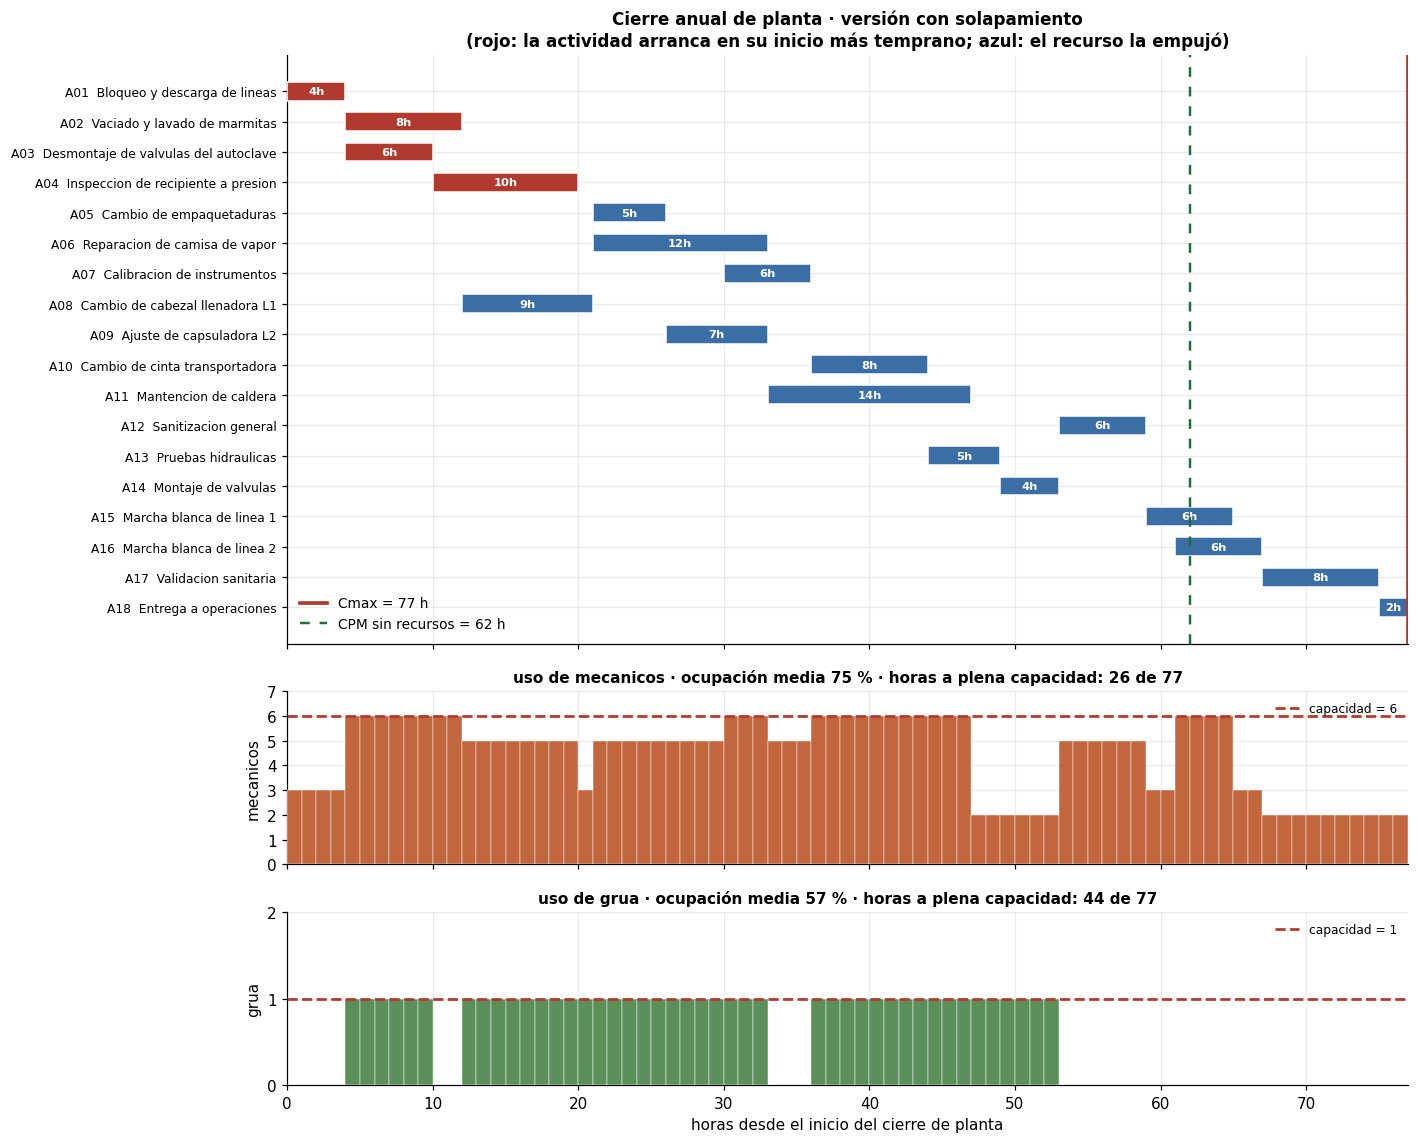

In [14]:
v_final = "solapada"
ini_final = SOL[v_final]["inicio"]
cmax_final = SOL[v_final]["Cmax"]
T_fin = int(cmax_final)

perfil = {r: [sum(uso.get((a, r), 0) for a in ACT
                  if ini_final[a] <= t < ini_final[a] + dur[a])
              for t in range(T_fin)] for r in RECURSOS}

fig, axes = plt.subplots(3, 1, figsize=(13, 10.5), sharex=True,
                         gridspec_kw={"height_ratios": [3.4, 1.0, 1.0]})

# --- panel 1: Gantt
ax = axes[0]
es_fin, _lg, _ps = cpm(REL[v_final])
critica = {a for a in ACT if abs(ini_final[a] - es_fin[a]) < 1e-6}
for i, a in enumerate(ACT):
    color = "#b03a2e" if a in critica else "#3b6ea5"
    ax.barh(i, dur[a], left=ini_final[a], height=0.62, color=color,
            edgecolor="white", linewidth=1.0, zorder=3)
    ax.text(ini_final[a] + dur[a] / 2, i, f"{dur[a]}h", ha="center",
            va="center", color="white", fontsize=7.5, fontweight="bold",
            zorder=4)
ax.set_yticks(range(len(ACT)))
ax.set_yticklabels([f"{a}  {nombre[a]}" for a in ACT], fontsize=8)
ax.invert_yaxis()
ax.axvline(cmax_final, color="#b03a2e", lw=2.4, zorder=5,
           label=f"Cmax = {cmax_final:.0f} h")
ax.axvline(CPM[v_final], color="#1f6f3d", lw=1.6, ls=(0, (4, 4)), zorder=5,
           label=f"CPM sin recursos = {CPM[v_final]:.0f} h")
ax.set_title("Cierre anual de planta · versión con solapamiento\n"
             "(rojo: la actividad arranca en su inicio más temprano; azul: "
             "el recurso la empujó)", fontsize=11)
ax.legend(fontsize=9, loc="lower left")
ax.grid(axis="x", alpha=0.25)

# --- paneles 2 y 3: perfil de recursos
colores_r = {"mecanicos": "#c1663d", "grua": "#5a8f5a"}
for k, r in enumerate(RECURSOS):
    axr = axes[k + 1]
    axr.bar(range(T_fin), perfil[r], width=1.0, align="edge",
            color=colores_r.get(r, "#8c6bb1"), edgecolor="white",
            linewidth=0.3, zorder=3)
    axr.axhline(cap[r], color="#b03a2e", lw=1.8, ls="--", zorder=4,
                label=f"capacidad = {cap[r]}")
    ocupacion = 100 * sum(perfil[r]) / (cap[r] * T_fin)
    axr.set_ylabel(r)
    axr.set_ylim(0, cap[r] + 1)
    axr.set_yticks(range(cap[r] + 2))
    axr.legend(fontsize=8, loc="upper right")
    axr.set_title(f"uso de {r} · ocupación media {ocupacion:.0f} % · "
                  f"horas a plena capacidad: "
                  f"{sum(1 for u in perfil[r] if u == cap[r])} de {T_fin}",
                  fontsize=10)
    axr.grid(axis="y", alpha=0.25)
axes[-1].set_xlabel("horas desde el inicio del cierre de planta")
axes[-1].set_xlim(0, cmax_final)

figura(fig, "rcpsp_gantt_y_recursos")
plt.show()

In [15]:
print("Calendario final (versión con solapamiento):\n")
plan = pd.DataFrame([
    {"actividad": a, "nombre": nombre[a], "inicio": ini_final[a],
     "fin": ini_final[a] + dur[a], "duracion_h": dur[a],
     "mecanicos": uso[(a, "mecanicos")], "grua": uso[(a, "grua")],
     "holgura_h": ini_final[a] - es_fin[a]}
    for a in ACT])
print(plan.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

print(f"\nLa relación con desfase negativo, vista en el plan:")
print(f"  A11 (caldera)       {ini_final['A11']:5.0f} -> "
      f"{ini_final['A11'] + dur['A11']:5.0f}")
print(f"  A13 (pruebas hidr.) {ini_final['A13']:5.0f} -> "
      f"{ini_final['A13'] + dur['A13']:5.0f}")
solape = (ini_final["A11"] + dur["A11"]) - ini_final["A13"]
print(f"  se solapan {max(0.0, solape):.0f} h  (el desfase permitía hasta 3 h)")

Calendario final (versión con solapamiento):

actividad                               nombre  inicio  fin  duracion_h  mecanicos  grua  holgura_h
      A01         Bloqueo y descarga de lineas       0    4           4          3     0        0.0
      A02         Vaciado y lavado de marmitas       4   12           8          4     0        0.0
      A03 Desmontaje de valvulas del autoclave       4   10           6          2     1        0.0
      A04   Inspeccion de recipiente a presion      10   20          10          2     0        0.0
      A05             Cambio de empaquetaduras      21   26           5          2     0       11.0
      A06        Reparacion de camisa de vapor      21   33          12          3     1        9.0
      A07          Calibracion de instrumentos      30   36           6          1     0       10.0
      A08       Cambio de cabezal llenadora L1      12   21           9          3     1        8.0
      A09             Ajuste de capsuladora L2      26

## 10. Comprobación

El valor que informa el solver es el de su objetivo. Que el calendario cumpla
las precedencias **en su forma nativa** es otra afirmación, y hay que
verificarla sobre inicios y finales según el tipo de cada relación, no sobre
la `δ` ya traducida: comprobar la traducción contra sí misma no detectaría un
error en la traducción.

In [16]:
print("Comprobación:")
ok = []
ok.append(verificar(cota_recurso["mecanicos"], 57.5, "cota recurso mecánicos (h)", tol=1e-9))
ok.append(verificar(cota_recurso["grua"], 44.0, "cota recurso grúa (h)", tol=1e-9))
print()
for v, cpm_ref, opt_ref in [("clasica", 63.0, 78.0), ("generalizada", 65.0, 80.0),
                            ("solapada", 62.0, 77.0)]:
    ok.append(verificar(CPM[v], cpm_ref, f"CPM · {ETIQUETA[v]} (h)", tol=1e-9))
    ok.append(verificar(SOL[v]["Cmax"], opt_ref, f"óptimo · {ETIQUETA[v]} (h)", tol=1e-6))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")


def verificar_calendario(v):
    """Comprobación independiente del calendario de una versión."""
    ini = SOL[v]["inicio"]
    fallas = []
    # (a) precedencias clasicas, en forma nativa
    pr = {b: list(x) for b, x in preds_archivo.items()}
    if v in ("clasica", "generalizada"):
        pr["A13"] = sorted(set(pr["A13"]) | {"A11"})
    for b, ps in pr.items():
        for a in ps:
            if ini[b] < ini[a] + dur[a] - 1e-6:
                fallas.append(f"FS {a}->{b}: {b} empieza en {ini[b]} y {a} "
                              f"termina en {ini[a] + dur[a]}")
    # (b) generalizadas, cada una en SU forma
    if v != "clasica":
        for (a, b, tipo, lag, _m) in GENERALIZADAS:
            if v == "generalizada" and (a, b) == ("A11", "A13"):
                continue
            fa, fb = ini[a] + dur[a], ini[b] + dur[b]
            izq, der = {"FS": (ini[b], fa + lag), "SS": (ini[b], ini[a] + lag),
                        "FF": (fb, fa + lag), "SF": (fb, ini[a] + lag)}[tipo]
            if izq < der - 1e-6:
                fallas.append(f"{tipo} {a}->{b}: {izq} < {der}")
    # (c) recursos, instante a instante
    fin = max(ini[a] + dur[a] for a in ACT)
    for r in RECURSOS:
        for t in range(fin):
            u = sum(uso.get((a, r), 0) for a in ACT if ini[a] <= t < ini[a] + dur[a])
            if u > cap[r]:
                fallas.append(f"recurso {r} en t={t}: usa {u} y hay {cap[r]}")
    # (d) el objetivo que se informa es el del calendario
    if abs(fin - SOL[v]["Cmax"]) > 1e-6:
        fallas.append(f"Cmax del calendario {fin} != solver {SOL[v]['Cmax']}")
    return fallas


for v in VARIANTES:
    fallas = verificar_calendario(v)
    assert not fallas, f"{v}: " + " | ".join(fallas[:5])
    print(f"  calendario de '{ETIQUETA[v]}' verificado: precedencias nativas, "
          f"recursos y objetivo")

# La leccion central, como asercion:
assert SOL["generalizada"]["Cmax"] > SOL["clasica"]["Cmax"] + 1e-6, \
    "escribir SS, FF y SF debe ALARGAR el proyecto: son restricciones reales"
assert SOL["solapada"]["Cmax"] < SOL["generalizada"]["Cmax"] - 1e-6, \
    "permitir el desfase negativo debe ACORTAR el proyecto"
# Y las cotas tienen que ser cotas.
for v in VARIANTES:
    assert SOL[v]["Cmax"] >= COTA[v] - 1e-6, f"{v}: el óptimo está bajo la cota"
    assert SOL[v]["estado"] == "OPTIMAL" and SOL[v]["gap_%"] < 1e-4, \
        f"{v}: el modelo no cerró"
# El modelo ingenuo tiene que fallar, y fallar de la forma que se dijo.
pico_mal = max(sum(uso.get((a, "mecanicos"), 0) for a in ACT
                   if mal["inicio"][a] <= t < mal["inicio"][a] + dur[a])
               for t in range(fin_mal))
assert pico_mal > cap["mecanicos"], \
    "el modelo con la restricción ingenua debería violar la capacidad"
assert abs(mal["Cmax"] - CPM["clasica"]) < 1e-6, \
    "con la restricción ingenua el RCPSP colapsa a su propio CPM"
# Los ciclos del archivo existen y son consistentes.
assert len(ciclos) >= 2, "el archivo debería producir ciclos en el grafo"
assert all(L <= 1e-9 for _c, L in ciclos), \
    "todos los ciclos del archivo deben ser consistentes (longitud <= 0)"
print("\nTodas las aserciones pasan.")

tabla(comparacion, "rcpsp_tres_versiones")
tabla(plan, "rcpsp_plan_optimo")
tabla(tabla_delta, "rcpsp_precedencias_generalizadas")
resumen({"cpm": {v: CPM[v] for v in VARIANTES},
         "optimo": {v: SOL[v]["Cmax"] for v in VARIANTES},
         "cota_recurso": cota_recurso,
         "cota_inferior": {v: COTA[v] for v in VARIANTES},
         "efecto_escribir_restricciones_reales":
             SOL["generalizada"]["Cmax"] - SOL["clasica"]["Cmax"],
         "efecto_permitir_solapamiento":
             SOL["solapada"]["Cmax"] - SOL["generalizada"]["Cmax"],
         "cmax_modelo_con_recurso_ingenuo": mal["Cmax"],
         "pico_mecanicos_modelo_ingenuo": int(pico_mal),
         "ciclos": [{"largo": L, "arcos": [f"{a}-{t}{l:+g}->{b}"
                                           for (a, b, t, l, _d) in c]}
                    for c, L in ciclos]},
        "resumen_rcpsp")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] cota recurso mecánicos (h): obtenido 57.5000 | referencia 57.5000 | dif. relativa 0.00e+00
  [  OK  ] cota recurso grúa (h): obtenido 44.0000 | referencia 44.0000 | dif. relativa 0.00e+00

  [  OK  ] CPM · solo FS con desfase 0 (h): obtenido 63.0000 | referencia 63.0000 | dif. relativa 0.00e+00
  [  OK  ] óptimo · solo FS con desfase 0 (h): obtenido 78.0000 | referencia 78.0000 | dif. relativa 0.00e+00
  [  OK  ] CPM · + SS, FF y SF (h): obtenido 65.0000 | referencia 65.0000 | dif. relativa 0.00e+00
  [  OK  ] óptimo · + SS, FF y SF (h): obtenido 80.0000 | referencia 80.0000 | dif. relativa 0.00e+00
  [  OK  ] CPM · + desfase −3 en A11→A13 (h): obtenido 62.0000 | referencia 62.0000 | dif. relativa 0.00e+00
  [  OK  ] óptimo · + desfase −3 en A11→A13 (h): obtenido 77.0000 | referencia 77.0000 | dif. relativa 0.00e+00

8/8 comprobaciones correctas
  calendario de 'solo FS con desfase 0' verificado: precedencias nativas, recursos y objetivo
  calendario de '+ SS, 

---

## Para llevarse

1. **La restricción de recurso es sobre las actividades ACTIVAS, no sobre las
   que arrancan.** `Σ_a u_ar Σ_{q=t−d_a+1}^{t} z_aq ≤ C_r`. Escribir
   `Σ_a u_ar z_at ≤ C_r` produce un modelo que devuelve OPTIMAL, colapsa al
   CPM sin recursos, y entrega un plan que exige 12 mecánicos donde hay 6.
   Nadie se entera hasta que la cuadrilla llega el lunes. La señal delatora es
   gratuita y hay que buscarla siempre: **si un RCPSP devuelve exactamente su
   propio CPM, sospechar de la restricción de recurso.**
2. **Las cuatro formas de precedencia son una sola desigualdad.** FS, SS, FF y
   SF con desfase de cualquier signo se reducen a `S_b ≥ S_a + δ(a,b)`. En el
   MIP cambia un coeficiente. Quien las presente como una extensión difícil
   del modelo no las ha escrito.
3. **Lo que se rompe está afuera del MIP.** Con desfases negativos el grafo de
   precedencias tiene ciclos, el CPM deja de ser un recorrido topológico y pasa
   a ser un camino más largo relajado a la Bellman-Ford, y el generador en
   serie clásico deja de servir porque las precedencias ya no ordenan nada.
   **Lo infactible no es el ciclo: es que su longitud sea positiva.** Y
   detectarlo antes del modelo es lo que permite decir cuál par de exigencias
   se contradice, en vez de un INFEASIBLE que no explica nada.
4. **Los dos efectos van en direcciones opuestas y no hay que mezclarlos.**
   Escribir las relaciones SS, FF y SF que la planta sí tiene **alarga** el
   proyecto de 78 a 80 h: el plan clásico no era ambicioso, era inejecutable.
   Permitir el solapamiento real lo baja a 77 h. Reportar solo el neto —una
   hora— esconde las dos cosas que efectivamente pasaron. Generalizar las
   precedencias no es optimizar más: es dejar de mentir en las dos direcciones
   a la vez.
5. **El modelo indexado en el tiempo crece con el horizonte.** Cada hora de
   más son `|A|` binarias más. Por eso el horizonte no se pone en `Σ d_a` sino
   en el makespan de una heurística factible, y las ventanas por actividad se
   recortan con el CPM hacia adelante y hacia atrás. Es la misma idea que el
   big-M ajustado del cuaderno 05, y acá **sí** se nota.

## Ejercicios

1. Cambie el desfase de `A11 → A13` de −3 a −10 h y vuelva a correr. ¿Cuánto
   baja el proyecto? Prediga antes de ejecutar: ¿puede bajar 7 h más, o hay
   otra cosa que lo detiene? Mire el CPM y las cotas de recurso antes de
   responder.
2. La sección 3 rompió la instancia subiendo el `SS` de `A15 → A16` a 5 h y el
   CPM detectó el ciclo positivo. Resuelva esa misma instancia rota con el MIP
   completo: ¿qué informa Gurobi? Compare la utilidad de los dos diagnósticos
   para ir a hablar con mantención.
3. Súbale un mecánico a la cuadrilla (capacidad 7) y vuelva a correr las tres
   versiones. ¿Bajan las tres lo mismo? Contraste el resultado con la cota de
   recurso de la sección 4 y con el perfil de uso de la sección 9: ¿estaban
   los mecánicos a plena capacidad las horas suficientes como para que el
   séptimo sirviera de algo?